In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, count, avg, to_date, month, year
import pandas as pd
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("AnalisisBatchVentas") \
    .getOrCreate()

print("Spark iniciado correctamente")

Spark iniciado correctamente


In [3]:
productos = [
    ("Laptop", "Tecnología", 2500000),
    ("Celular", "Tecnología", 1200000),
    ("Audífonos", "Tecnología", 180000),
    ("Silla Gamer", "Hogar", 650000),
    ("Escritorio", "Hogar", 480000),
    ("Camiseta", "Ropa", 70000),
    ("Zapatos", "Ropa", 180000),
    ("Maleta", "Accesorios", 220000),
    ("Reloj", "Accesorios", 350000),
    ("Tablet", "Tecnología", 900000)
]

ciudades = ["Bogotá", "Medellín", "Cali", "Barranquilla", "Cartagena", "Bucaramanga"]

data = []

fecha_inicio = datetime(2025, 1, 1)

for i in range(10000):
    producto, categoria, precio_base = random.choice(productos)
    ciudad = random.choice(ciudades)
    cantidad = random.randint(1, 5)
    precio_unitario = precio_base + random.randint(-50000, 50000)
    fecha = fecha_inicio + timedelta(days=random.randint(0, 364))

    data.append({
        "id_venta": i + 1,
        "fecha": fecha.strftime("%Y-%m-%d"),
        "producto": producto,
        "categoria": categoria,
        "ciudad": ciudad,
        "cantidad": cantidad,
        "precio_unitario": precio_unitario
    })

df_pandas = pd.DataFrame(data)

df_pandas.to_csv("ventas.csv", index=False)

df_pandas.head()

,id_venta,fecha,producto,categoria,ciudad,cantidad,precio_unitario
0,1,2025-07-12,Silla Gamer,Hogar,Bucaramanga,5,653564
1,2,2025-04-03,Laptop,Tecnología,Cali,5,2545103
2,3,2025-11-21,Silla Gamer,Hogar,Bucaramanga,2,601699
3,4,2025-03-19,Celular,Tecnología,Bucaramanga,1,1207335
4,5,2025-01-02,Silla Gamer,Hogar,Bucaramanga,3,622120


In [4]:
df = spark.read.csv("ventas.csv", header=True, inferSchema=True)

print("Esquema del dataset:")
df.printSchema()

print("Primeros registros:")
df.show(10)

Esquema del dataset:
root
 |-- id_venta: integer (nullable = true)
 |-- fecha: date (nullable = true)
 |-- producto: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- cantidad: integer (nullable = true)
 |-- precio_unitario: integer (nullable = true)

Primeros registros:
+--------+----------+-----------+----------+-----------+--------+---------------+
|id_venta|     fecha|   producto| categoria|     ciudad|cantidad|precio_unitario|
+--------+----------+-----------+----------+-----------+--------+---------------+
|       1|2025-07-12|Silla Gamer|     Hogar|Bucaramanga|       5|         653564|
|       2|2025-04-03|     Laptop|Tecnología|       Cali|       5|        2545103|
|       3|2025-11-21|Silla Gamer|     Hogar|Bucaramanga|       2|         601699|
|       4|2025-03-19|    Celular|Tecnología|Bucaramanga|       1|        1207335|
|       5|2025-01-02|Silla Gamer|     Hogar|Bucaramanga|       3|         622120|
|       6|202

In [5]:
print("Cantidad de registros iniciales:", df.count())

df_clean = df.dropna()

print("Cantidad de registros después de eliminar nulos:", df_clean.count())

df_clean = df_clean.withColumn("fecha", to_date(col("fecha")))

print("Esquema después de limpieza:")
df_clean.printSchema()

print("Primeros registros limpios:")
df_clean.show(5)

Cantidad de registros iniciales: 10000
Cantidad de registros después de eliminar nulos: 10000
Esquema después de limpieza:
root
 |-- id_venta: integer (nullable = true)
 |-- fecha: date (nullable = true)
 |-- producto: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- cantidad: integer (nullable = true)
 |-- precio_unitario: integer (nullable = true)

Primeros registros limpios:
+--------+----------+-----------+----------+-----------+--------+---------------+
|id_venta|     fecha|   producto| categoria|     ciudad|cantidad|precio_unitario|
+--------+----------+-----------+----------+-----------+--------+---------------+
|       1|2025-07-12|Silla Gamer|     Hogar|Bucaramanga|       5|         653564|
|       2|2025-04-03|     Laptop|Tecnología|       Cali|       5|        2545103|
|       3|2025-11-21|Silla Gamer|     Hogar|Bucaramanga|       2|         601699|
|       4|2025-03-19|    Celular|Tecnología|Bucaramanga|       1|  

In [7]:
df_transformado = df_clean.withColumn(
    "total_venta",
    col("cantidad") * col("precio_unitario")
)

df_transformado = df_transformado.withColumn("año", year(col("fecha")))
df_transformado = df_transformado.withColumn("mes", month(col("fecha")))

print("Dataset transformado:")
df_transformado.show(10)

Dataset transformado:
+--------+----------+-----------+----------+-----------+--------+---------------+-----------+----+---+
|id_venta|     fecha|   producto| categoria|     ciudad|cantidad|precio_unitario|total_venta| año|mes|
+--------+----------+-----------+----------+-----------+--------+---------------+-----------+----+---+
|       1|2025-07-12|Silla Gamer|     Hogar|Bucaramanga|       5|         653564|    3267820|2025|  7|
|       2|2025-04-03|     Laptop|Tecnología|       Cali|       5|        2545103|   12725515|2025|  4|
|       3|2025-11-21|Silla Gamer|     Hogar|Bucaramanga|       2|         601699|    1203398|2025| 11|
|       4|2025-03-19|    Celular|Tecnología|Bucaramanga|       1|        1207335|    1207335|2025|  3|
|       5|2025-01-02|Silla Gamer|     Hogar|Bucaramanga|       3|         622120|    1866360|2025|  1|
|       6|2025-08-28|    Zapatos|      Ropa|     Bogotá|       4|         193661|     774644|2025|  8|
|       7|2025-06-23|     Laptop|Tecnología|  Carta

In [9]:
df_transformado = df_clean.withColumn(
    "total_venta",
    col("cantidad") * col("precio_unitario")
)

df_transformado = df_transformado.withColumn("año", year(col("fecha")))
df_transformado = df_transformado.withColumn("mes", month(col("fecha")))

print("Dataset transformado:")
df_transformado.show(10)

Dataset transformado:
+--------+----------+-----------+----------+-----------+--------+---------------+-----------+----+---+
|id_venta|     fecha|   producto| categoria|     ciudad|cantidad|precio_unitario|total_venta| año|mes|
+--------+----------+-----------+----------+-----------+--------+---------------+-----------+----+---+
|       1|2025-07-12|Silla Gamer|     Hogar|Bucaramanga|       5|         653564|    3267820|2025|  7|
|       2|2025-04-03|     Laptop|Tecnología|       Cali|       5|        2545103|   12725515|2025|  4|
|       3|2025-11-21|Silla Gamer|     Hogar|Bucaramanga|       2|         601699|    1203398|2025| 11|
|       4|2025-03-19|    Celular|Tecnología|Bucaramanga|       1|        1207335|    1207335|2025|  3|
|       5|2025-01-02|Silla Gamer|     Hogar|Bucaramanga|       3|         622120|    1866360|2025|  1|
|       6|2025-08-28|    Zapatos|      Ropa|     Bogotá|       4|         193661|     774644|2025|  8|
|       7|2025-06-23|     Laptop|Tecnología|  Carta

In [10]:
ventas_categoria = df_transformado.groupBy("categoria") \
    .agg(sum("total_venta").alias("ingresos_totales")) \
    .orderBy(col("ingresos_totales").desc())

print("Ingresos totales por categoría:")
ventas_categoria.show()

Ingresos totales por categoría:
+----------+----------------+
| categoria|ingresos_totales|
+----------+----------------+
|Tecnología|     14104305721|
|     Hogar|      3454480599|
|Accesorios|      1766180698|
|      Ropa|       728502539|
+----------+----------------+



In [11]:
ventas_ciudad = df_transformado.groupBy("ciudad") \
    .agg(sum("total_venta").alias("ingresos_totales")) \
    .orderBy(col("ingresos_totales").desc())

print("Ingresos totales por ciudad:")
ventas_ciudad.show()

Ingresos totales por ciudad:
+------------+----------------+
|      ciudad|ingresos_totales|
+------------+----------------+
|      Bogotá|      3460825169|
|    Medellín|      3452181761|
|        Cali|      3389199911|
| Bucaramanga|      3273200469|
|Barranquilla|      3239337108|
|   Cartagena|      3238725139|
+------------+----------------+



In [12]:
ventas_mes = df_transformado.groupBy("mes") \
    .agg(
        count("*").alias("cantidad_ventas"),
        sum("total_venta").alias("ingresos_totales")
    ) \
    .orderBy("mes")

print("Cantidad de ventas e ingresos por mes:")
ventas_mes.show()

Cantidad de ventas e ingresos por mes:
+---+---------------+----------------+
|mes|cantidad_ventas|ingresos_totales|
+---+---------------+----------------+
|  1|            850|      1594011865|
|  2|            791|      1682909358|
|  3|            890|      1706075774|
|  4|            813|      1658466804|
|  5|            884|      1684081209|
|  6|            821|      1718547852|
|  7|            817|      1615712196|
|  8|            853|      1694471861|
|  9|            820|      1651137467|
| 10|            849|      1674303900|
| 11|            768|      1557139980|
| 12|            844|      1816611291|
+---+---------------+----------------+



In [14]:
ventas_producto = df_transformado.groupBy("producto") \
    .agg(sum("total_venta").alias("ingresos_totales")) \
    .orderBy(col("ingresos_totales").desc())

print("Ingresos totales por producto:")
ventas_producto.show()

Ingresos totales por producto:
+-----------+----------------+
|   producto|ingresos_totales|
+-----------+----------------+
|     Laptop|      7582077892|
|    Celular|      3334645506|
|     Tablet|      2666597307|
|Silla Gamer|      1988149645|
| Escritorio|      1466330954|
|      Reloj|      1094513797|
|     Maleta|       671666901|
|  Audífonos|       520985016|
|    Zapatos|       519449563|
|   Camiseta|       209052976|
+-----------+----------------+



In [15]:
ventas_categoria = df_transformado.groupBy("categoria") \
    .agg(sum("total_venta").alias("ingresos_totales")) \
    .orderBy(col("ingresos_totales").desc())

print("Ingresos totales por categoría:")
ventas_categoria.show()

Ingresos totales por categoría:
+----------+----------------+
| categoria|ingresos_totales|
+----------+----------------+
|Tecnología|     14104305721|
|     Hogar|      3454480599|
|Accesorios|      1766180698|
|      Ropa|       728502539|
+----------+----------------+



In [16]:
ventas_ciudad = df_transformado.groupBy("ciudad") \
    .agg(sum("total_venta").alias("ingresos_totales")) \
    .orderBy(col("ingresos_totales").desc())

print("Ingresos totales por ciudad:")
ventas_ciudad.show()

Ingresos totales por ciudad:
+------------+----------------+
|      ciudad|ingresos_totales|
+------------+----------------+
|      Bogotá|      3460825169|
|    Medellín|      3452181761|
|        Cali|      3389199911|
| Bucaramanga|      3273200469|
|Barranquilla|      3239337108|
|   Cartagena|      3238725139|
+------------+----------------+



In [17]:
ventas_mes = df_transformado.groupBy("mes") \
    .agg(
        count("*").alias("cantidad_ventas"),
        sum("total_venta").alias("ingresos_totales")
    ) \
    .orderBy("mes")

print("Cantidad de ventas e ingresos por mes:")
ventas_mes.show()

Cantidad de ventas e ingresos por mes:
+---+---------------+----------------+
|mes|cantidad_ventas|ingresos_totales|
+---+---------------+----------------+
|  1|            850|      1594011865|
|  2|            791|      1682909358|
|  3|            890|      1706075774|
|  4|            813|      1658466804|
|  5|            884|      1684081209|
|  6|            821|      1718547852|
|  7|            817|      1615712196|
|  8|            853|      1694471861|
|  9|            820|      1651137467|
| 10|            849|      1674303900|
| 11|            768|      1557139980|
| 12|            844|      1816611291|
+---+---------------+----------------+



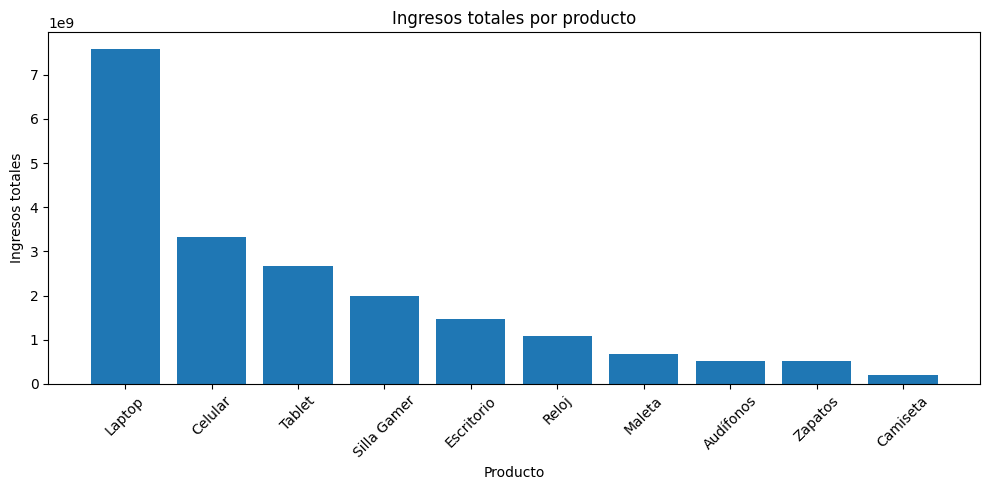

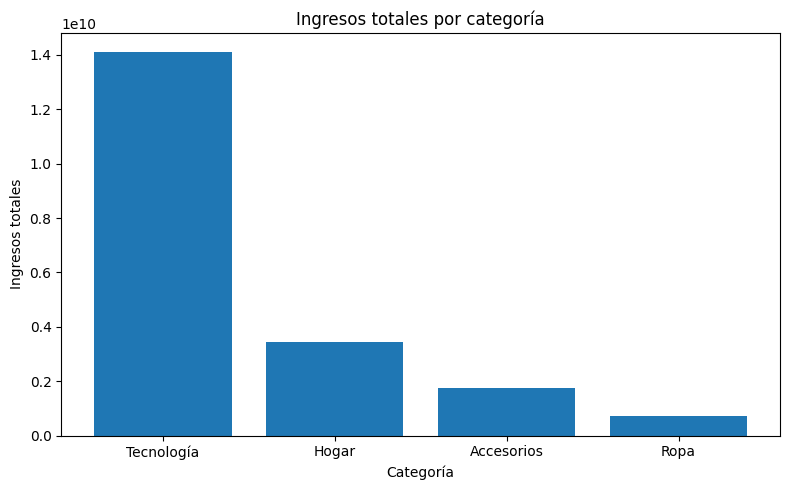

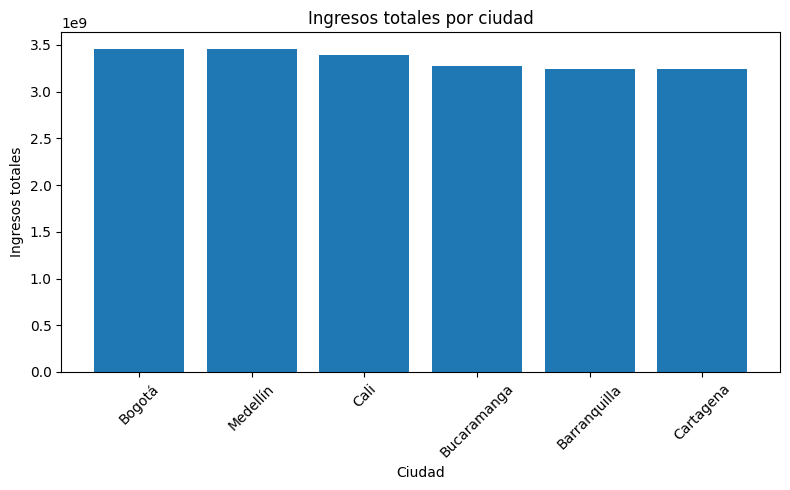

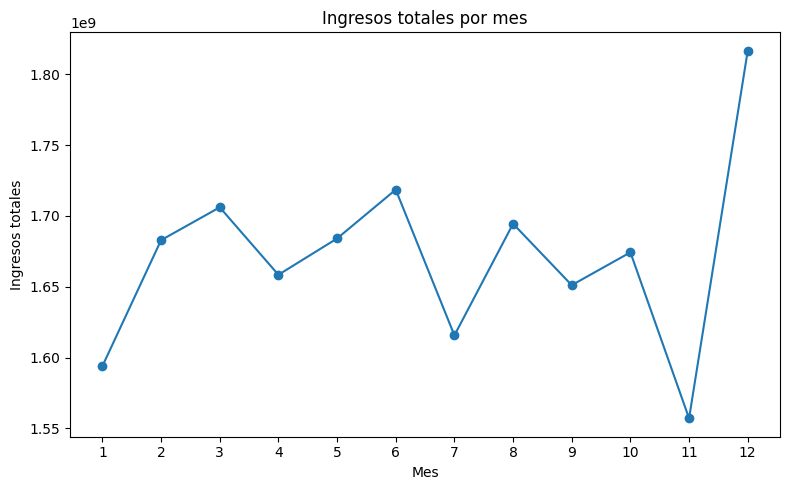

In [18]:
ventas_producto_pd = ventas_producto.toPandas()
ventas_categoria_pd = ventas_categoria.toPandas()
ventas_ciudad_pd = ventas_ciudad.toPandas()
ventas_mes_pd = ventas_mes.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(ventas_producto_pd["producto"], ventas_producto_pd["ingresos_totales"])
plt.title("Ingresos totales por producto")
plt.xlabel("Producto")
plt.ylabel("Ingresos totales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(ventas_categoria_pd["categoria"], ventas_categoria_pd["ingresos_totales"])
plt.title("Ingresos totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ingresos totales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(ventas_ciudad_pd["ciudad"], ventas_ciudad_pd["ingresos_totales"])
plt.title("Ingresos totales por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Ingresos totales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(ventas_mes_pd["mes"], ventas_mes_pd["ingresos_totales"], marker="o")
plt.title("Ingresos totales por mes")
plt.xlabel("Mes")
plt.ylabel("Ingresos totales")
plt.xticks(ventas_mes_pd["mes"])
plt.tight_layout()
plt.show()

In [19]:
ventas_producto.coalesce(1).write.csv("resultado_ventas_producto", header=True, mode="overwrite")
ventas_categoria.coalesce(1).write.csv("resultado_ventas_categoria", header=True, mode="overwrite")
ventas_ciudad.coalesce(1).write.csv("resultado_ventas_ciudad", header=True, mode="overwrite")
ventas_mes.coalesce(1).write.csv("resultado_ventas_mes", header=True, mode="overwrite")

print("Resultados exportados correctamente")

Resultados exportados correctamente


# Procesamiento en tiempo real con Spark Streaming y Kafka


In [20]:
!pip install -q pyspark==3.5.3 kafka-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.1/326.1 kB 14.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.3 which is incompatible.


In [22]:
!wget -q https://downloads.apache.org/kafka/3.8.0/kafka_2.12-3.8.0.tgz
!tar -xzf kafka_2.12-3.8.0.tgz
!mv kafka_2.12-3.8.0 kafka

print("Kafka descargado y descomprimido correctamente")

tar (child): kafka_2.12-3.8.0.tgz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now
mv: cannot stat 'kafka_2.12-3.8.0': No such file or directory
Kafka descargado y descomprimido correctamente


In [23]:
!rm -rf kafka kafka_2.12-3.8.0 kafka_2.12-3.8.0.tgz
print("Limpieza completada")

Limpieza completada


In [24]:
!wget https://archive.apache.org/dist/kafka/3.8.0/kafka_2.12-3.8.0.tgz

--2026-05-18 03:29:03--  https://archive.apache.org/dist/kafka/3.8.0/kafka_2.12-3.8.0.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 120900366 (115M) [application/x-gzip]
Saving to: ‘kafka_2.12-3.8.0.tgz’

kafka_2.12-3.8.0.tg 100%[===================>] 115.30M   759KB/s    in 2m 14s  

2026-05-18 03:31:17 (883 KB/s) - ‘kafka_2.12-3.8.0.tgz’ saved [120900366/120900366]



In [25]:
!tar -xzf kafka_2.12-3.8.0.tgz
!mv kafka_2.12-3.8.0 kafka

print("Kafka descargado y descomprimido correctamente")

Kafka descargado y descomprimido correctamente


In [26]:
!ls kafka

bin  config  libs  LICENSE  licenses  NOTICE  site-docs


In [27]:
!nohup ./kafka/bin/zookeeper-server-start.sh ./kafka/config/zookeeper.properties > zookeeper.log 2>&1 &

import time
time.sleep(10)

print("ZooKeeper iniciado")

ZooKeeper iniciado


In [28]:
!nohup ./kafka/bin/kafka-server-start.sh ./kafka/config/server.properties > kafka.log 2>&1 &

import time
time.sleep(15)

print("Kafka iniciado")

Kafka iniciado


In [29]:
!tail -n 20 kafka.log

[2026-05-18 03:33:21,134] INFO [GroupCoordinator 0]: Startup complete. (kafka.coordinator.group.GroupCoordinator)
[2026-05-18 03:33:21,149] INFO Feature ZK node created at path: /feature (kafka.server.FinalizedFeatureChangeListener)
[2026-05-18 03:33:21,163] INFO [TransactionCoordinator id=0] Starting up. (kafka.coordinator.transaction.TransactionCoordinator)
[2026-05-18 03:33:21,181] INFO [TxnMarkerSenderThread-0]: Starting (kafka.coordinator.transaction.TransactionMarkerChannelManager)
[2026-05-18 03:33:21,182] INFO [TransactionCoordinator id=0] Startup complete. (kafka.coordinator.transaction.TransactionCoordinator)
[2026-05-18 03:33:21,259] INFO [MetadataCache brokerId=0] Updated cache from existing None to latest Features(metadataVersion=3.8-IV0, finalizedFeatures={}, finalizedFeaturesEpoch=0). (kafka.server.metadata.ZkMetadataCache)
[2026-05-18 03:33:21,301] INFO [ExpirationReaper-0-AlterAcls]: Starting (kafka.server.DelayedOperationPurgatory$ExpiredOperationReaper)
[2026-05-18 0

In [30]:
!./kafka/bin/kafka-topics.sh --create --bootstrap-server localhost:9092 --replication-factor 1 --partitions 1 --topic sensor_data

Created topic sensor_data.


In [31]:
!./kafka/bin/kafka-topics.sh --list --bootstrap-server localhost:9092

sensor_data


In [32]:
%%writefile kafka_producer.py
import time
import json
import random
from kafka import KafkaProducer

def generate_sensor_data():
    return {
        "sensor_id": random.randint(1, 10),
        "temperature": round(random.uniform(20, 30), 2),
        "humidity": round(random.uniform(30, 70), 2),
        "timestamp": int(time.time())
    }

producer = KafkaProducer(
    bootstrap_servers=["localhost:9092"],
    value_serializer=lambda x: json.dumps(x).encode("utf-8")
)

for i in range(120):
    sensor_data = generate_sensor_data()
    producer.send("sensor_data", value=sensor_data)
    print(f"Sent: {sensor_data}")
    time.sleep(1)

producer.flush()
producer.close()

Writing kafka_producer.py


In [33]:
!nohup python3 kafka_producer.py > producer.log 2>&1 &

In [34]:
import time
time.sleep(5)

!tail -n 10 producer.log

In [35]:
!ls -lh producer.log

-rw-r--r-- 1 root root 8.1K May 18 03:39 producer.log


In [36]:
!tail -n 20 producer.log

Sent: {'sensor_id': 9, 'temperature': 29.4, 'humidity': 32.29, 'timestamp': 1779075570}
Sent: {'sensor_id': 5, 'temperature': 24.9, 'humidity': 56.77, 'timestamp': 1779075571}
Sent: {'sensor_id': 9, 'temperature': 29.4, 'humidity': 42.66, 'timestamp': 1779075572}
Sent: {'sensor_id': 2, 'temperature': 22.84, 'humidity': 34.21, 'timestamp': 1779075573}
Sent: {'sensor_id': 10, 'temperature': 20.92, 'humidity': 63.35, 'timestamp': 1779075574}
Sent: {'sensor_id': 9, 'temperature': 27.89, 'humidity': 32.66, 'timestamp': 1779075575}
Sent: {'sensor_id': 6, 'temperature': 25.47, 'humidity': 32.64, 'timestamp': 1779075576}
Sent: {'sensor_id': 6, 'temperature': 20.5, 'humidity': 64.6, 'timestamp': 1779075577}
Sent: {'sensor_id': 2, 'temperature': 20.98, 'humidity': 43.36, 'timestamp': 1779075578}
Sent: {'sensor_id': 5, 'temperature': 21.35, 'humidity': 47.54, 'timestamp': 1779075579}
Sent: {'sensor_id': 4, 'temperature': 22.37, 'humidity': 33.13, 'timestamp': 1779075580}
Sent: {'sensor_id': 10, '

In [37]:
%%writefile spark_streaming_consumer.py
from pyspark.sql import SparkSession
from pyspark.sql.functions import from_json, col, window, from_unixtime
from pyspark.sql.types import StructType, StructField, IntegerType, FloatType, LongType

spark = SparkSession.builder \
    .appName("KafkaSparkStreaming") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

schema = StructType([
    StructField("sensor_id", IntegerType(), True),
    StructField("temperature", FloatType(), True),
    StructField("humidity", FloatType(), True),
    StructField("timestamp", LongType(), True)
])

df = spark \
    .readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", "localhost:9092") \
    .option("subscribe", "sensor_data") \
    .option("startingOffsets", "earliest") \
    .load()

parsed_df = df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

parsed_df = parsed_df.withColumn(
    "event_time",
    from_unixtime(col("timestamp")).cast("timestamp")
)

windowed_stats = parsed_df \
    .groupBy(
        window(col("event_time"), "1 minute"),
        col("sensor_id")
    ) \
    .avg("temperature", "humidity")

query = windowed_stats \
    .writeStream \
    .outputMode("complete") \
    .format("console") \
    .option("truncate", "false") \
    .trigger(processingTime="10 seconds") \
    .start()

query.awaitTermination(60)

query.stop()
spark.stop()

Writing spark_streaming_consumer.py


In [38]:
!spark-submit --packages org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.3 spark_streaming_consumer.py

:: loading settings :: url = jar:file:/usr/local/lib/python3.12/dist-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ad36b3ac-0da6-4b05-90d5-132d52b132ab;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.5.3 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.5.3 in central
	found org.apache.kafka#kafka-clients;3.4.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.10.5 in central
	found org.slf4j#slf4j-api;2.0.7 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.4 in central
	found org.apache.hadoop#hadoop-client-api;3.3.4 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;